# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ahmedfurqan1/FlyRank-MachineLearning/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The playbook uses the validated fixed baseline. A page enters the queue when it had at least 100 March impressions, zero March clicks, and an average search position greater than 0 and no worse than 20. Eligible pages are ranked by March impressions, with identifiers used only to break ties deterministically.

The reason code `visible_zero_ctr_top20` means the page had meaningful exposure and no measured clicks while ranking within the top 20. It supports review priority, but it does not identify the cause or guarantee that editing the page will recover traffic. The score is relative exposure on a 0–1 scale, not a probability.

Every queued page begins with the archetype `diagnosis_required`. A human reviewer must distinguish snippet or intent mismatch from tracking, indexing, demand, or lifecycle conditions before selecting an action.

In [1]:
import getpass
import sys

import duckdb
import numpy as np
import pandas as pd
from IPython.display import display

try:
    from google.colab import userdata
    hf_token = userdata.get("HF_TOKEN")
except Exception:
    hf_token = None

if not hf_token:
    hf_token = getpass.getpass("Enter your Hugging Face READ token: ")

if not hf_token.startswith("hf_"):
    raise ValueError("A valid Hugging Face READ token is required.")

con = duckdb.connect()
safe_token = hf_token.replace("'", "''")

con.execute(
    f"""
    CREATE OR REPLACE SECRET flyrank_hf (
        TYPE huggingface,
        TOKEN '{safe_token}'
    )
    """
)

del hf_token, safe_token

WAREHOUSE_ROOT = "hf://datasets/FlyRank/internship-warehouse"
MARCH_FACT = (
    f"{WAREHOUSE_ROOT}/fact_content_daily_performance/"
    "month=2026-03/*.parquet"
)
OBSERVATION_MONTH = "2026-03"
OUTCOME_MONTH = "2026-04"
SEALED_TEST_MONTH = "2026-06"
LOADED_MONTHS = (OBSERVATION_MONTH,)
RANDOM_SEED = 42
OPERATIONAL_K = 50

assert OUTCOME_MONTH not in LOADED_MONTHS
assert SEALED_TEST_MONTH not in LOADED_MONTHS

print(f"Python version: {sys.version.split()[0]}")
print(f"DuckDB version: {duckdb.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Observation month loaded: {OBSERVATION_MONTH}")
print(f"Outcome month loaded: no")
print(f"Sealed test month loaded: no")
print(f"Operational review capacity: {OPERATIONAL_K}")

Python version: 3.13.15
DuckDB version: 1.3.2
pandas version: 2.2.3
NumPy version: 2.1.3
Observation month loaded: 2026-03
Outcome month loaded: no
Sealed test month loaded: no
Operational review capacity: 50


In [2]:
action_queue = con.execute(
    f"""
    WITH march AS (
        SELECT
            client_hash_id,
            content_hash_id,
            SUM(gsc_impressions) AS march_impressions_count,
            SUM(gsc_clicks) AS march_clicks_count,
            SUM(gsc_sum_position)
                / NULLIF(SUM(gsc_impressions), 0) AS march_avg_position
        FROM read_parquet('{MARCH_FACT}')
        WHERE gsc_data_available IS TRUE
        GROUP BY client_hash_id, content_hash_id
    )

    SELECT
        client_hash_id,
        content_hash_id,
        march_impressions_count,
        march_clicks_count,
        100.0 * march_clicks_count
            / NULLIF(march_impressions_count, 0) AS march_ctr_pct,
        march_avg_position
    FROM march
    WHERE march_impressions_count >= 100
      AND march_clicks_count = 0
      AND march_avg_position > 0
      AND march_avg_position <= 20
    """
).df()

action_queue = (
    action_queue.sort_values(
        [
            "march_impressions_count",
            "client_hash_id",
            "content_hash_id",
        ],
        ascending=[False, True, True],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

action_queue["action_rank"] = np.arange(1, len(action_queue) + 1)
maximum_impressions_count = action_queue["march_impressions_count"].max()
action_queue["action_score_0_1"] = (
    action_queue["march_impressions_count"] / maximum_impressions_count
)
action_queue["reason_code"] = "visible_zero_ctr_top20"
action_queue["review_archetype"] = "diagnosis_required"
action_queue["recommended_review_action"] = "review_search_snippet_and_page_status"
action_queue["requires_human_review"] = True
action_queue["automation_status"] = "do_not_auto_edit"

action_queue = action_queue[
    [
        "action_rank",
        "client_hash_id",
        "content_hash_id",
        "action_score_0_1",
        "reason_code",
        "review_archetype",
        "recommended_review_action",
        "requires_human_review",
        "automation_status",
        "march_impressions_count",
        "march_clicks_count",
        "march_ctr_pct",
        "march_avg_position",
    ]
]

review_archetype_mapping = pd.DataFrame(
    [
        {
            "review_archetype": "snippet_or_intent_mismatch",
            "possible_action": "review_title_meta_and_intent_match",
            "automation_status": "human_approval_required",
        },
        {
            "review_archetype": "tracking_anomaly",
            "possible_action": "validate_measurement_before_action",
            "automation_status": "do_not_auto_edit",
        },
        {
            "review_archetype": "indexing_or_technical_issue",
            "possible_action": "route_to_technical_seo_review",
            "automation_status": "do_not_auto_edit",
        },
        {
            "review_archetype": "demand_or_serp_change",
            "possible_action": "monitor_or_research_query_change",
            "automation_status": "do_not_auto_edit",
        },
        {
            "review_archetype": "intentional_retirement",
            "possible_action": "remove_from_refresh_queue",
            "automation_status": "do_not_auto_edit",
        },
    ]
)

forbidden_columns = {
    "april_impressions_count",
    "is_declining_label",
    "trend_direction",
    "trend_pct",
}

assert len(action_queue) > 0
assert forbidden_columns.isdisjoint(action_queue.columns)
assert action_queue["action_rank"].is_unique
assert action_queue["action_rank"].is_monotonic_increasing
assert action_queue["action_score_0_1"].between(0, 1).all()
assert action_queue["march_impressions_count"].ge(100).all()
assert action_queue["march_clicks_count"].eq(0).all()
assert action_queue["march_ctr_pct"].eq(0).all()
assert action_queue["march_avg_position"].gt(0).all()
assert action_queue["march_avg_position"].le(20).all()
assert action_queue["requires_human_review"].all()

queue_summary = pd.DataFrame(
    [
        {
            "queue_count": len(action_queue),
            "operational_k_count": OPERATIONAL_K,
            "reason_code": action_queue["reason_code"].iloc[0],
            "minimum_march_impressions_count": int(
                action_queue["march_impressions_count"].min()
            ),
            "maximum_march_impressions_count": int(
                action_queue["march_impressions_count"].max()
            ),
        }
    ]
)

anonymous_top_actions = action_queue.head(10)[
    [
        "action_rank",
        "action_score_0_1",
        "reason_code",
        "recommended_review_action",
        "march_impressions_count",
        "march_clicks_count",
        "march_ctr_pct",
        "march_avg_position",
    ]
].copy()

anonymous_top_actions.insert(
    0,
    "anonymous_item_label",
    [f"action_item_{rank}" for rank in anonymous_top_actions["action_rank"]],
)

print("Queue summary")
display(queue_summary)

print("Reviewer-assigned archetype mapping")
display(review_archetype_mapping)

print("Anonymized top-ranked actions")
display(anonymous_top_actions)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Queue summary


,queue_count,operational_k_count,reason_code,minimum_march_impressions_count,maximum_march_impressions_count
0,24012,50,visible_zero_ctr_top20,100,44707


Reviewer-assigned archetype mapping


,review_archetype,possible_action,automation_status
0,snippet_or_intent_mismatch,review_title_meta_and_intent_match,human_approval_required
1,tracking_anomaly,validate_measurement_before_action,do_not_auto_edit
2,indexing_or_technical_issue,route_to_technical_seo_review,do_not_auto_edit
3,demand_or_serp_change,monitor_or_research_query_change,do_not_auto_edit
4,intentional_retirement,remove_from_refresh_queue,do_not_auto_edit


Anonymized top-ranked actions


,anonymous_item_label,action_rank,action_score_0_1,reason_code,recommended_review_action,march_impressions_count,march_clicks_count,march_ctr_pct,march_avg_position
0,action_item_1,1,1.000000,visible_zero_ctr_top20,review_search_snippet_and_page_status,44707.0,0.0,0.0,1.400049
1,action_item_2,2,0.869327,visible_zero_ctr_top20,review_search_snippet_and_page_status,38865.0,0.0,0.0,4.804554
2,action_item_3,3,0.647550,visible_zero_ctr_top20,review_search_snippet_and_page_status,28950.0,0.0,0.0,9.563005
3,action_item_4,4,0.557139,visible_zero_ctr_top20,review_search_snippet_and_page_status,24908.0,0.0,0.0,3.431106
4,action_item_5,5,0.481334,visible_zero_ctr_top20,review_search_snippet_and_page_status,21519.0,0.0,0.0,5.347182
5,action_item_6,6,0.445970,visible_zero_ctr_top20,review_search_snippet_and_page_status,19938.0,0.0,0.0,10.909118
6,action_item_7,7,0.431521,visible_zero_ctr_top20,review_search_snippet_and_page_status,19292.0,0.0,0.0,8.243572
7,action_item_8,8,0.382826,visible_zero_ctr_top20,review_search_snippet_and_page_status,17115.0,0.0,0.0,6.012854
8,action_item_9,9,0.355694,visible_zero_ctr_top20,review_search_snippet_and_page_status,15902.0,0.0,0.0,8.564017
9,action_item_10,10,0.331335,visible_zero_ctr_top20,review_search_snippet_and_page_status,14813.0,0.0,0.0,3.130493


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

This queue helps an SEO manager or content editor select up to 50 pages for diagnosis during a review cycle. Ranking reflects affected March search exposure: a higher score means more impressions were associated with the observed zero-click pattern. It does not estimate recovery probability or monetary return.

The fixed baseline measured 68.8% mean Precision@50 and 75.0% Precision@20 across five client-grouped March-to-April folds, compared with a 51.1% outcome base rate. This supports directional enrichment for held-out clients from the same period. It does not guarantee future-period performance, and the broader March-only operational queue is not identical to the matched evaluation population.

The referenced FlyRank research observed that recently refreshed mature pages had higher health scores and impressions than stale mature pages. That is a directional refresh insight, not proof that refreshing caused improvement: page selection, prior performance, timing, topic, and client mix may explain part of the difference.

In [3]:
GROUPED_BASELINE_PRECISION_AT_50_PCT = 68.8
GROUPED_BASELINE_PRECISION_AT_20_PCT = 75.0
OUTCOME_BASE_RATE_PCT = 51.1

top_k_queue = action_queue.head(OPERATIONAL_K)
queue_reviewed_pct = 100.0 * len(top_k_queue) / len(action_queue)
top_k_impressions_count = int(top_k_queue["march_impressions_count"].sum())
queue_impressions_count = int(action_queue["march_impressions_count"].sum())
top_k_exposure_share_pct = (
    100.0 * top_k_impressions_count / queue_impressions_count
)

capacity_value_summary = pd.DataFrame(
    [
        {
            "queue_count": len(action_queue),
            "operational_k_count": OPERATIONAL_K,
            "queue_reviewed_pct": queue_reviewed_pct,
            "top_k_impressions_count": top_k_impressions_count,
            "queue_impressions_count": queue_impressions_count,
            "top_k_exposure_share_pct": top_k_exposure_share_pct,
            "value_proxy": "march_impressions_count",
            "monetary_roi_available": False,
        }
    ]
)

validation_evidence = pd.DataFrame(
    [
        {
            "metric": "precision_at_50_pct",
            "fixed_baseline_pct": GROUPED_BASELINE_PRECISION_AT_50_PCT,
            "reference_base_rate_pct": OUTCOME_BASE_RATE_PCT,
            "enrichment_pp": (
                GROUPED_BASELINE_PRECISION_AT_50_PCT
                - OUTCOME_BASE_RATE_PCT
            ),
        },
        {
            "metric": "precision_at_20_pct",
            "fixed_baseline_pct": GROUPED_BASELINE_PRECISION_AT_20_PCT,
            "reference_base_rate_pct": OUTCOME_BASE_RATE_PCT,
            "enrichment_pp": (
                GROUPED_BASELINE_PRECISION_AT_20_PCT
                - OUTCOME_BASE_RATE_PCT
            ),
        },
    ]
)

assert len(top_k_queue) == OPERATIONAL_K
assert 0 < queue_reviewed_pct < 100
assert 0 < top_k_exposure_share_pct <= 100
assert validation_evidence["enrichment_pp"].gt(0).all()
assert capacity_value_summary["monetary_roi_available"].eq(False).all()

print("Operational capacity and value proxy")
display(capacity_value_summary.round(2))

print("Established grouped-validation evidence")
display(validation_evidence.round(1))

Operational capacity and value proxy


,queue_count,operational_k_count,queue_reviewed_pct,top_k_impressions_count,queue_impressions_count,top_k_exposure_share_pct,value_proxy,monetary_roi_available
0,24012,50,0.21,604300,12751788,4.74,march_impressions_count,False


Established grouped-validation evidence


,metric,fixed_baseline_pct,reference_base_rate_pct,enrichment_pp
0,precision_at_50_pct,68.8,51.1,17.7
1,precision_at_20_pct,75.0,51.1,23.9


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Every recommendation requires human diagnosis. The reviewer must check measurement integrity, indexing and technical status, query intent, demand or seasonality, recent changes, and whether the page is still strategically relevant. Query-level details may be inspected only in an authorized system and must not be displayed in this notebook.

The score must not trigger automatic title edits, content rewrites, publishing, deletion, redirects, or pruning. Reviewers should abstain when tracking is suspicious, the page is intentionally retired, ownership is unclear, evidence conflicts, or the proposed action carries legal, brand, medical, financial, or reputational risk.

A false positive wastes editorial time and may damage a healthy page. A false negative leaves a potentially important decline unreviewed. The queue controls review order only; the human reviewer owns the diagnosis and action decision.

In [4]:
human_review_rules = pd.DataFrame(
    [
        {
            "review_order": 1,
            "review_check": "measurement_integrity",
            "required_verification": "confirm_impressions_clicks_and_tracking_are_plausible",
        },
        {
            "review_order": 2,
            "review_check": "indexing_and_technical_status",
            "required_verification": "check_indexing_canonical_redirect_and_availability",
        },
        {
            "review_order": 3,
            "review_check": "query_intent_and_serp_context",
            "required_verification": "inspect_privately_in_an_authorized_system",
        },
        {
            "review_order": 4,
            "review_check": "demand_and_seasonality",
            "required_verification": "check_whether_external_demand_changed",
        },
        {
            "review_order": 5,
            "review_check": "recent_page_changes",
            "required_verification": "check_for_recent_edits_migrations_or_experiments",
        },
        {
            "review_order": 6,
            "review_check": "business_and_content_status",
            "required_verification": "confirm_ownership_relevance_and_page_lifecycle",
        },
    ]
)

no_go_cases = pd.DataFrame(
    [
        {
            "no_go_case": "automatic_content_or_metadata_edit",
            "required_response": "require_human_approval",
        },
        {
            "no_go_case": "automatic_publish_delete_redirect_or_prune",
            "required_response": "prohibit_automatic_action",
        },
        {
            "no_go_case": "score_used_as_recovery_probability",
            "required_response": "treat_as_ranking_score_only",
        },
        {
            "no_go_case": "suspicious_or_incomplete_measurement",
            "required_response": "hold_and_validate_data",
        },
        {
            "no_go_case": "unclear_ownership_or_page_purpose",
            "required_response": "abstain_and_route_to_owner",
        },
        {
            "no_go_case": "sensitive_or_high_risk_content",
            "required_response": "route_to_qualified_specialist",
        },
        {
            "no_go_case": "private_identifiers_or_queries_in_outputs",
            "required_response": "prohibit_display_or_public_export",
        },
    ]
)

action_queue["human_review_status"] = "pending"
action_queue["review_decision"] = "undecided"
action_queue["reviewer_archetype"] = "not_yet_assigned"

assert human_review_rules["review_order"].is_unique
assert human_review_rules["review_order"].is_monotonic_increasing
assert no_go_cases["no_go_case"].is_unique
assert action_queue["requires_human_review"].all()
assert action_queue["automation_status"].eq("do_not_auto_edit").all()
assert action_queue["human_review_status"].eq("pending").all()
assert action_queue["review_decision"].eq("undecided").all()

print("Mandatory human-review sequence")
display(human_review_rules)

print("Actions and conditions that must not be automated")
display(no_go_cases)

Mandatory human-review sequence


,review_order,review_check,required_verification
0,1,measurement_integrity,confirm_impressions_clicks_and_tracking_are_pl...
1,2,indexing_and_technical_status,check_indexing_canonical_redirect_and_availabi...
2,3,query_intent_and_serp_context,inspect_privately_in_an_authorized_system
3,4,demand_and_seasonality,check_whether_external_demand_changed
4,5,recent_page_changes,check_for_recent_edits_migrations_or_experiments
5,6,business_and_content_status,confirm_ownership_relevance_and_page_lifecycle


Actions and conditions that must not be automated


,no_go_case,required_response
0,automatic_content_or_metadata_edit,require_human_approval
1,automatic_publish_delete_redirect_or_prune,prohibit_automatic_action
2,score_used_as_recovery_probability,treat_as_ranking_score_only
3,suspicious_or_incomplete_measurement,hold_and_validate_data
4,unclear_ownership_or_page_purpose,abstain_and_route_to_owner
5,sensitive_or_high_risk_content,route_to_qualified_specialist
6,private_identifiers_or_queries_in_outputs,prohibit_display_or_public_export


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

The queue should be regenerated monthly after a complete observation window. Each run must verify its schema, deterministic ordering, score bounds, data availability, and sealed-period exclusion. A queue-count change above 25% from the March reference triggers investigation because it may indicate genuine drift or a pipeline problem.

Once later outcomes are available, grouped Precision@50 should be tracked over consecutive cycles. A decline of more than 10 percentage points from the 68.8% reference, or performance no better than the relevant outcome base rate, triggers a data and rule audit. Retraining is considered only if degradation persists for two cycles.

Human decisions are also monitoring evidence. High abstention, repeated tracking anomalies, or missing review outcomes indicate that the queue is not sufficiently actionable. These thresholds are practical governance proposals and should be revised as operating history accumulates.

In [5]:
REFERENCE_QUEUE_COUNT = 24012
QUEUE_COUNT_CHANGE_TRIGGER_PCT = 25.0
PRECISION_AT_50_DROP_TRIGGER_PP = 10.0
HUMAN_ABSTENTION_TRIGGER_PCT = 50.0
PERSISTENCE_TRIGGER_CYCLES_COUNT = 2

queue_count_change_pct = (
    100.0
    * abs(len(action_queue) - REFERENCE_QUEUE_COUNT)
    / REFERENCE_QUEUE_COUNT
)

monitoring_triggers = pd.DataFrame(
    [
        {
            "monitor_name": "pipeline_and_schema_integrity",
            "review_frequency": "every_run",
            "trigger_rule": "any_assertion_or_export_failure",
            "required_response": "stop_queue_and_investigate",
        },
        {
            "monitor_name": "queue_count_drift",
            "review_frequency": "every_monthly_run",
            "trigger_rule": "absolute_change_exceeds_25_pct",
            "required_response": "audit_data_coverage_and_rule_population",
        },
        {
            "monitor_name": "realized_precision_at_50",
            "review_frequency": "when_outcomes_mature",
            "trigger_rule": "drop_exceeds_10_pp_or_no_better_than_base_rate",
            "required_response": "audit_data_rule_and_validation",
        },
        {
            "monitor_name": "human_abstention",
            "review_frequency": "every_review_cycle",
            "trigger_rule": "abstention_exceeds_50_pct",
            "required_response": "review_reason_codes_and_actionability",
        },
        {
            "monitor_name": "tracking_anomaly_frequency",
            "review_frequency": "every_review_cycle",
            "trigger_rule": "repeated_growth_across_two_cycles",
            "required_response": "route_to_measurement_owner",
        },
        {
            "monitor_name": "persistent_performance_degradation",
            "review_frequency": "after_two_mature_cycles",
            "trigger_rule": "performance_trigger_repeats_for_two_cycles",
            "required_response": "consider_rule_revision_or_model_retraining",
        },
    ]
)

current_queue_monitor = pd.DataFrame(
    [
        {
            "reference_queue_count": REFERENCE_QUEUE_COUNT,
            "current_queue_count": len(action_queue),
            "queue_count_change_pct": queue_count_change_pct,
            "queue_count_change_trigger_pct": QUEUE_COUNT_CHANGE_TRIGGER_PCT,
            "is_queue_count_triggered": (
                queue_count_change_pct > QUEUE_COUNT_CHANGE_TRIGGER_PCT
            ),
            "is_sealed_test_month_excluded": (
                SEALED_TEST_MONTH not in LOADED_MONTHS
            ),
            "performance_monitor_status": "not_yet_observed",
            "human_review_monitor_status": "not_yet_observed",
        }
    ]
)

assert current_queue_monitor["is_queue_count_triggered"].eq(False).all()
assert current_queue_monitor["is_sealed_test_month_excluded"].all()
assert current_queue_monitor["performance_monitor_status"].eq(
    "not_yet_observed"
).all()
assert current_queue_monitor["human_review_monitor_status"].eq(
    "not_yet_observed"
).all()

print("Monitoring and retrain triggers")
display(monitoring_triggers)

print("Checks available in the current run")
display(current_queue_monitor.round(2))

Monitoring and retrain triggers


,monitor_name,review_frequency,trigger_rule,required_response
0,pipeline_and_schema_integrity,every_run,any_assertion_or_export_failure,stop_queue_and_investigate
1,queue_count_drift,every_monthly_run,absolute_change_exceeds_25_pct,audit_data_coverage_and_rule_population
2,realized_precision_at_50,when_outcomes_mature,drop_exceeds_10_pp_or_no_better_than_base_rate,audit_data_rule_and_validation
3,human_abstention,every_review_cycle,abstention_exceeds_50_pct,review_reason_codes_and_actionability
4,tracking_anomaly_frequency,every_review_cycle,repeated_growth_across_two_cycles,route_to_measurement_owner
5,persistent_performance_degradation,after_two_mature_cycles,performance_trigger_repeats_for_two_cycles,consider_rule_revision_or_model_retraining


Checks available in the current run


,reference_queue_count,current_queue_count,queue_count_change_pct,queue_count_change_trigger_pct,is_queue_count_triggered,is_sealed_test_month_excluded,performance_monitor_status,human_review_monitor_status
0,24012,24012,0.0,25.0,False,True,not_yet_observed,not_yet_observed


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

The ranked operational queue is exported to `work/outputs/w07_ranked_action_queue.csv`. It contains pseudonymous identifiers for authorized internal traceability and must remain outside Git. It contains March decision-time fields only; no April outcome, label, query, URL, or sealed-period field is exported.

The aggregate metrics receipt is exported to `work/outputs/w07_action_playbook_metrics.json`, and the grouped-validation figure is saved under `work/figures/`. These public-safe files preserve the evidence and limits needed by the research paper.

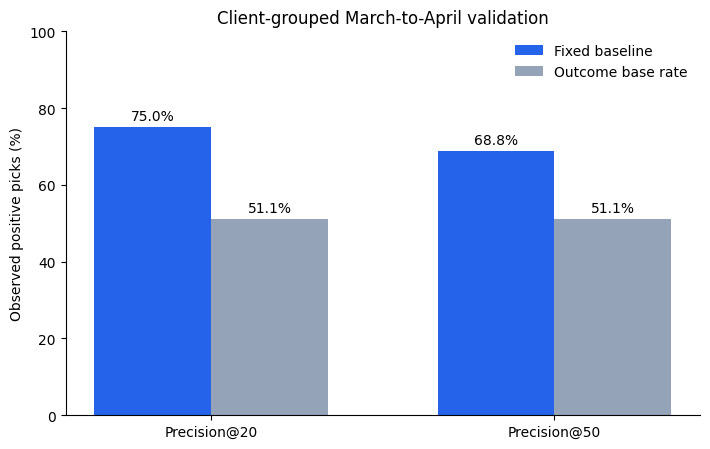

,artifact_path,artifact_purpose,file_size_bytes_count,commit_status
0,work/outputs/w07_ranked_action_queue.csv,private_ranked_action_queue,5461795,do_not_commit_gitignored
1,work/outputs/w07_action_playbook_metrics.json,public_safe_metrics_receipt,1272,commit
2,work/figures/w07_grouped_validation.png,public_safe_paper_figure,61810,commit


In [6]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

outputs_directory = Path("work/outputs")
figures_directory = Path("work/figures")
outputs_directory.mkdir(parents=True, exist_ok=True)
figures_directory.mkdir(parents=True, exist_ok=True)

queue_output_path = outputs_directory / "w07_ranked_action_queue.csv"
metrics_output_path = outputs_directory / "w07_action_playbook_metrics.json"
figure_output_path = figures_directory / "w07_grouped_validation.png"

export_queue_columns = [
    "action_rank",
    "client_hash_id",
    "content_hash_id",
    "action_score_0_1",
    "reason_code",
    "review_archetype",
    "recommended_review_action",
    "requires_human_review",
    "automation_status",
    "human_review_status",
    "review_decision",
    "march_impressions_count",
    "march_clicks_count",
    "march_ctr_pct",
    "march_avg_position",
]

export_queue = action_queue[export_queue_columns].copy()
export_queue.to_csv(queue_output_path, index=False)

metrics_receipt = {
    "assignment": "w07_action_playbook",
    "selected_method": "fixed_baseline",
    "observation_month": OBSERVATION_MONTH,
    "outcome_month_used_for_prior_validation": OUTCOME_MONTH,
    "sealed_test_month": SEALED_TEST_MONTH,
    "sealed_test_month_loaded": False,
    "operational_queue_uses_march_only": True,
    "operational_k_count": OPERATIONAL_K,
    "operational_queue_count": int(len(action_queue)),
    "queue_reviewed_pct": round(float(queue_reviewed_pct), 4),
    "top_k_impressions_count": top_k_impressions_count,
    "queue_impressions_count": queue_impressions_count,
    "top_k_exposure_share_pct": round(
        float(top_k_exposure_share_pct), 4
    ),
    "validation_design": "five_fold_groupkfold_by_client",
    "validation_scope": "grouped_development_validation_not_sealed_test",
    "outcome_base_rate_pct": OUTCOME_BASE_RATE_PCT,
    "grouped_baseline_precision_at_20_pct": (
        GROUPED_BASELINE_PRECISION_AT_20_PCT
    ),
    "grouped_baseline_precision_at_50_pct": (
        GROUPED_BASELINE_PRECISION_AT_50_PCT
    ),
    "decline_threshold_pct": -15.0,
    "reason_code": "visible_zero_ctr_top20",
    "ranking_value_proxy": "march_impressions_count",
    "score_interpretation": "relative_exposure_ranking_not_probability",
    "requires_human_review": True,
    "automatic_editing_allowed": False,
    "queue_count_change_trigger_pct": (
        QUEUE_COUNT_CHANGE_TRIGGER_PCT
    ),
    "precision_at_50_drop_trigger_pp": (
        PRECISION_AT_50_DROP_TRIGGER_PP
    ),
    "human_abstention_trigger_pct": (
        HUMAN_ABSTENTION_TRIGGER_PCT
    ),
    "persistence_trigger_cycles_count": (
        PERSISTENCE_TRIGGER_CYCLES_COUNT
    ),
    "claim_limit": (
        "decision_support_only_no_causal_or_future_performance_claim"
    ),
}

with metrics_output_path.open("w", encoding="utf-8") as metrics_file:
    json.dump(metrics_receipt, metrics_file, indent=2)

metric_labels = ["Precision@20", "Precision@50"]
baseline_metric_pct = [
    GROUPED_BASELINE_PRECISION_AT_20_PCT,
    GROUPED_BASELINE_PRECISION_AT_50_PCT,
]
base_rate_metric_pct = [
    OUTCOME_BASE_RATE_PCT,
    OUTCOME_BASE_RATE_PCT,
]

figure, axis = plt.subplots(figsize=(7.2, 4.6))
x_positions = np.arange(len(metric_labels))
bar_width = 0.34

baseline_bars = axis.bar(
    x_positions - bar_width / 2,
    baseline_metric_pct,
    bar_width,
    label="Fixed baseline",
    color="#2563EB",
)
base_rate_bars = axis.bar(
    x_positions + bar_width / 2,
    base_rate_metric_pct,
    bar_width,
    label="Outcome base rate",
    color="#94A3B8",
)

axis.set_ylabel("Observed positive picks (%)")
axis.set_title("Client-grouped March-to-April validation")
axis.set_xticks(x_positions, metric_labels)
axis.set_ylim(0, 100)
axis.legend(frameon=False)
axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)
axis.bar_label(baseline_bars, fmt="%.1f%%", padding=3)
axis.bar_label(base_rate_bars, fmt="%.1f%%", padding=3)
figure.tight_layout()
figure.savefig(figure_output_path, dpi=200, bbox_inches="tight")
plt.show()

forbidden_export_columns = {
    "april_impressions_count",
    "is_declining_label",
    "trend_direction",
    "trend_pct",
    "query_text",
    "url",
}

with metrics_output_path.open("r", encoding="utf-8") as metrics_file:
    verified_metrics_receipt = json.load(metrics_file)

assert queue_output_path.exists()
assert metrics_output_path.exists()
assert figure_output_path.exists()
assert forbidden_export_columns.isdisjoint(export_queue.columns)
assert export_queue["action_rank"].is_unique
assert export_queue["action_score_0_1"].between(0, 1).all()
assert export_queue["requires_human_review"].all()
assert export_queue["automation_status"].eq("do_not_auto_edit").all()
assert verified_metrics_receipt["sealed_test_month_loaded"] is False
assert verified_metrics_receipt["automatic_editing_allowed"] is False

export_manifest = pd.DataFrame(
    [
        {
            "artifact_path": str(queue_output_path),
            "artifact_purpose": "private_ranked_action_queue",
            "file_size_bytes_count": queue_output_path.stat().st_size,
            "commit_status": "do_not_commit_gitignored",
        },
        {
            "artifact_path": str(metrics_output_path),
            "artifact_purpose": "public_safe_metrics_receipt",
            "file_size_bytes_count": metrics_output_path.stat().st_size,
            "commit_status": "commit",
        },
        {
            "artifact_path": str(figure_output_path),
            "artifact_purpose": "public_safe_paper_figure",
            "file_size_bytes_count": figure_output_path.stat().st_size,
            "commit_status": "commit",
        },
    ]
)

display(export_manifest)

The automated checks verify the ranked queue, leakage protections, human-review controls, sealed-period exclusion, and exported artifacts. They do not verify future performance, causal impact, or whether a reviewer will follow the playbook.

The notebook must still be run twice from fresh runtimes. Split and validation metrics come from the established Week 6 grouped audit; this notebook regenerates the March-only operational queue without opening April or June.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.